In [1]:
import pd
from pystac_client import Client
from datetime import datetime
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import requests
import xarray as xr
from shapely import geometry

# Set up a local cluster for distributed computing.
from distributed import LocalCluster

Setup


In [2]:
# Create local processing cluster
cluster = LocalCluster()
client = cluster.get_client()

harz_boundaries = gpd.read_file("../resources/Nationalpark_Harz_boundaries.geojson")
bbox = harz_boundaries.geometry.values[0].bounds
catalog = Client.open("https://stac.core.eopf.eodc.eu")

In [3]:
results = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime=["2018-04-30", "2025-05-01"],
)
items = results.item_collection()

sr_datasets = []

for item in items:
    # Open SR_20m asset for this item
    ds = xr.open_dataset(item.assets["SR_10m"].href, engine="eopf-zarr", chunks={}, decode_timedelta=True)

    # Expand a time dimension using the item's timestamp
    ds = ds.expand_dims(time=pd.to_datetime([item.datetime]))

    sr_datasets.append(ds)

# Combine all items into one Dataset along time
r10m = xr.concat(sr_datasets, dim="time", join="outer")

In [4]:
import xarray as xr
import zarr
import dask.array as da
import pandas as pd

catalog = Client.open("https://stac.core.eopf.eodc.eu")
results = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime=["2025-04-20", "2025-05-01"],
)
items = results.item_collection()

sr_datasets = []

for item in items:
    # ------------------------------------------------------------------
    # 1. Open SR_20m
    # ------------------------------------------------------------------
    ds = xr.open_dataset(
        item.assets["SR_20m"].href,
        engine="eopf-zarr",
        chunks={}
    )

    # ------------------------------------------------------------------
    # 2. Open SCL_20m as a Dask-backed DataArray
    # ------------------------------------------------------------------
    scl_z = zarr.open(item.assets["SCL_20m"].href, mode="r")
    scl_da = xr.DataArray(
        da.from_array(scl_z, chunks=scl_z.chunks),
        dims=("y", "x"),
        name="scl"
    )

    # ------------------------------------------------------------------
    # 3. Add SCL as a new variable to the dataset
    # ------------------------------------------------------------------
    ds = ds.assign(scl=scl_da)

    # ------------------------------------------------------------------
    # 4. Add time dimension consistent with SR dataset
    # ------------------------------------------------------------------
    ds = ds.expand_dims(time=[pd.to_datetime(item.datetime)])

    sr_datasets.append(ds)

# ----------------------------------------------------------------------
# 5. Combine all datasets into a single time stack
# ----------------------------------------------------------------------
r20m_mask_l2a_classification = xr.concat(sr_datasets, dim="time", join="outer")
r20m_mask_l2a_classification

<xarray.Dataset> Size: 48GB
Dimensions:      (time: 10, y: 5490, x: 10491)
Coordinates:
  * time         (time) datetime64[ns, tzutc()] 80B 2025-04-30 10:27:01.02400...
  * y            (y) int64 44kB 5800010 5799990 5799970 ... 5690250 5690230
  * x            (x) int64 84kB 499990 500010 500030 ... 709750 709770 709790
    spatial_ref  int64 8B 0
Data variables:
    b01          (time, y, x) float64 5GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b02          (time, y, x) float64 5GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b03          (time, y, x) float64 5GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b04          (time, y, x) float64 5GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b05          (time, y, x) float64 5GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b06          (time, y, x) float64 5GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b07          (time, y, x) float64 5GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b11          (time, y, x) float64 5GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b12          (time, y, x) float64 5GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b8a          (time, y, x) float64 5GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    scl          (time, y, x) float32 2GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>

In [6]:

factor = 2
r100m = r10m.coarsen(x=factor, y=factor, boundary="trim").mean()
r100m

<xarray.Dataset> Size: 448GB
Dimensions:      (time: 243, y: 5490, x: 10491)
Coordinates:
  * time         (time) datetime64[ns, tzutc()] 2kB 2025-04-30 10:27:01.02400...
  * y            (y) float64 44kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
  * x            (x) float64 84kB 5e+05 5e+05 5e+05 ... 7.098e+05 7.098e+05
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 112GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b03          (time, y, x) float64 112GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b04          (time, y, x) float64 112GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b08          (time, y, x) float64 112GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>

In [9]:

target_chunks = {dim: ch[0] for dim, ch in zip(r100m["b02"].dims, r100m["b02"].chunks)}

# Interpolate and rechunk the SCL layer
scl_100m = (
    r20m_mask_l2a_classification.scl
    .chunk({"x": -1, "y": -1})  # merge chunks along x and y for interpolation
    .interp(x=r100m["x"], y=r100m["y"], method="nearest")
    .chunk(target_chunks)        # apply target chunks from r100m
)

scl_100m

<xarray.DataArray 'scl' (time: 10, y: 5490, x: 10491)> Size: 2GB
dask.array<rechunk-merge, shape=(10, 5490, 10491), dtype=float32, chunksize=(1, 915, 915), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns, tzutc()] 80B 2025-04-30 10:27:01.02400...
  * y            (y) float64 44kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
  * x            (x) float64 84kB 5e+05 5e+05 5e+05 ... 7.098e+05 7.098e+05
    spatial_ref  int64 8B 0

In [11]:
import pandas as pd

# Convert scl_100m time to timezone-naive
scl_100m = scl_100m.assign_coords(
    time=pd.to_datetime(scl_100m.time.values).tz_localize(None)
)

# Convert r100m time to timezone-naive as well
r100m = r100m.assign_coords(
    time=pd.to_datetime(r100m.time.values).tz_localize(None)
)


In [12]:
# Pick the first (and only) timestamp
r100m = r100m.isel(time=0)
scl_100m = scl_100m.isel(time=0)

# Reintroduce time as length-1 dimension
timestamp = pd.to_datetime(r10m.time.values[0]).tz_localize(None)
r100m = r100m.expand_dims(time=[timestamp])
scl_100m = scl_100m.expand_dims(time=[timestamp])

In [13]:
from modules.utils import validate_scl

valid_mask = validate_scl(scl_100m)
valid_r100m = r100m.where(valid_mask)
valid_r100m

<xarray.Dataset> Size: 2GB
Dimensions:      (time: 1, y: 5490, x: 10491)
Coordinates:
  * time         (time) datetime64[ns] 8B 2025-04-30T10:27:01.024000
  * y            (y) float64 44kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
  * x            (x) float64 84kB 5e+05 5e+05 5e+05 ... 7.098e+05 7.098e+05
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 461MB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b03          (time, y, x) float64 461MB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b04          (time, y, x) float64 461MB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b08          (time, y, x) float64 461MB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>

In [14]:
scale = valid_r100m["b04"].attrs["_eopf_attrs"]["scale_factor"]
offset = valid_r100m["b08"].attrs["_eopf_attrs"]["add_offset"]
reflectances_r100m = (valid_r100m * scale) + offset

In [15]:
b08 = reflectances_r100m["b08"]
b04 = reflectances_r100m["b04"]
ndvi = (b08 - b04) / (b08 + b04)  # Per-pixel NDVI
reflectances_r100m["ndvi"] = ndvi
reflectances_r100m

<xarray.Dataset> Size: 2GB
Dimensions:      (time: 1, x: 10491, y: 5490)
Coordinates:
  * time         (time) datetime64[ns] 8B 2025-04-30T10:27:01.024000
  * x            (x) float64 84kB 5e+05 5e+05 5e+05 ... 7.098e+05 7.098e+05
  * y            (y) float64 44kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 461MB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b03          (time, y, x) float64 461MB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b04          (time, y, x) float64 461MB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b08          (time, y, x) float64 461MB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    ndvi         (time, y, x) float64 461MB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>

In [16]:
polygon = gpd.read_file("../resources/Nationalpark_Harz_boundaries.geojson")
polygon.explore()

In [17]:
epsg = 32632

bbox_reproj = polygon.to_crs("epsg:" + str(epsg))
bbox_reproj = bbox_reproj.buffer(500)
bbox_reproj = bbox_reproj.total_bounds
bbox_reproj

array([ 590693.9546967 , 5724596.18681595,  613873.26643684,
       5751722.53201598])

In [18]:
#Check Duplicates
import numpy as np

print(np.unique(reflectances_r100m.time.values).size)
print(reflectances_r100m.time.size)
reflectances_r100m = reflectances_r100m.isel(
    time=~reflectances_r100m.get_index("time").duplicated()
)

1
1


In [19]:
cloudless_bands_ndvi = reflectances_r100m.sel(
    time=pd.Timestamp("2025-04-30"), method="nearest"
)

x_slice = slice(bbox_reproj[0], bbox_reproj[2])  # ~100 pixels
y_slice = slice(bbox_reproj[3], bbox_reproj[1])  # ~100 pixels

region = cloudless_bands_ndvi.sel(x=x_slice, y=y_slice).chunk(
    {"y": "auto", "x": "auto"}
)
region

<xarray.Dataset> Size: 63MB
Dimensions:      (x: 1159, y: 1356)
Coordinates:
  * x            (x) float64 9kB 5.907e+05 5.907e+05 ... 6.138e+05 6.139e+05
  * y            (y) float64 11kB 5.752e+06 5.752e+06 ... 5.725e+06 5.725e+06
    time         datetime64[ns] 8B 2025-04-30T10:27:01.024000
    spatial_ref  int64 8B 0
Data variables:
    b02          (y, x) float64 13MB dask.array<chunksize=(1356, 1159), meta=np.ndarray>
    b03          (y, x) float64 13MB dask.array<chunksize=(1356, 1159), meta=np.ndarray>
    b04          (y, x) float64 13MB dask.array<chunksize=(1356, 1159), meta=np.ndarray>
    b08          (y, x) float64 13MB dask.array<chunksize=(1356, 1159), meta=np.ndarray>
    ndvi         (y, x) float64 13MB dask.array<chunksize=(1356, 1159), meta=np.ndarray>

In [20]:
rgb = region[["b04", "b03", "b02"]].to_dataarray(dim="bands")
rgb = (rgb - 0.02) / (0.35 - 0.02)  # Stretch 0.02-0.35 to 0-1
rgb = rgb.clip(0, 1).compute()
ndvi = region["ndvi"].compute()
ndvi

D:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\distributed\client.py:3374: UserWarning: Sending large graph of size 79.43 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
D:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\distributed\client.py:3374: UserWarning: Sending large graph of size 68.51 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<xarray.DataArray 'ndvi' (y: 1356, x: 1159)> Size: 13MB
array([[        nan,         nan,         nan, ..., -0.00016585,
        -0.00016392, -0.00017891],
       [        nan,         nan,         nan, ..., -0.00015924,
        -0.00016136, -0.00017095],
       [        nan,         nan,         nan, ..., -0.00015308,
        -0.00015693, -0.00016208],
       ...,
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan]], shape=(1356, 1159))
Coordinates:
  * y            (y) float64 11kB 5.752e+06 5.752e+06 ... 5.725e+06 5.725e+06
  * x            (x) float64 9kB 5.907e+05 5.907e+05 ... 6.138e+05 6.139e+05
    time         datetime64[ns] 8B 2025-04-30T10:27:01.024000
    spatial_ref  int64 8B 0
Attributes: (11)

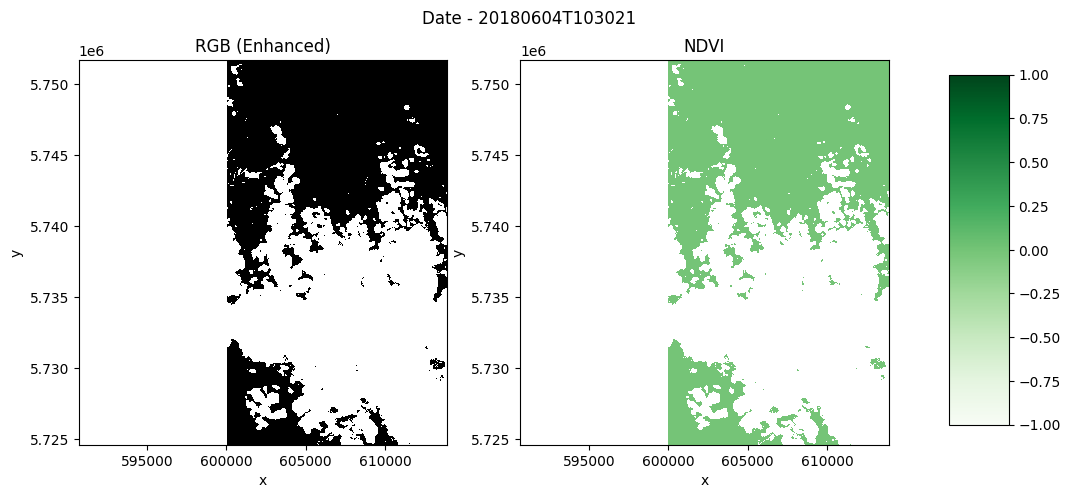

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Date - 20180604T103021\n")

# First subplot
rgb.plot.imshow(
    ax=ax1,
    rgb="bands",
    extent=(x_slice.start, x_slice.stop, y_slice.start, y_slice.stop),
)

ax1.set_title("RGB (Enhanced)")

# Second plot
ndvi_plot = ndvi.plot(ax=ax2, cmap="Greens", vmin=-1, vmax=1, add_colorbar=False)
ax2.set_title("NDVI")

# Add color bar on the right
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.colorbar(ndvi_plot, cax=cbar_ax)

In [22]:
# Group by year and compute mean

reflectances_r100m_naive = reflectances_r100m.assign_coords(
    time=pd.to_datetime(reflectances_r100m.time.values).tz_localize(None)
)

yearly_ds = (
    reflectances_r100m_naive.sel(x=x_slice, y=y_slice)
    .groupby("time.year")
    .mean(dim="time", skipna=True)
)
yearly_ds

<xarray.Dataset> Size: 63MB
Dimensions:      (year: 1, y: 1356, x: 1159)
Coordinates:
  * year         (year) int64 8B 2025
  * y            (y) float64 11kB 5.752e+06 5.752e+06 ... 5.725e+06 5.725e+06
  * x            (x) float64 9kB 5.907e+05 5.907e+05 ... 6.138e+05 6.139e+05
    spatial_ref  int64 8B 0
Data variables:
    b02          (year, y, x) float64 13MB dask.array<chunksize=(1, 330, 39), meta=np.ndarray>
    b03          (year, y, x) float64 13MB dask.array<chunksize=(1, 330, 39), meta=np.ndarray>
    b04          (year, y, x) float64 13MB dask.array<chunksize=(1, 330, 39), meta=np.ndarray>
    b08          (year, y, x) float64 13MB dask.array<chunksize=(1, 330, 39), meta=np.ndarray>
    ndvi         (year, y, x) float64 13MB dask.array<chunksize=(1, 330, 39), meta=np.ndarray>

In [23]:
def plot_rgb_ndvi(dset, year, x_slice, y_slice):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Date - " + str(year) + "\n")

    # First subplot
    rgb = dset[["b04", "b03", "b02"]].to_dataarray(dim="bands")
    rgb = (rgb - 0.02) / (0.35 - 0.02)  # Stretch 0.02-0.35 to 0-1
    rgb = rgb.clip(0, 1)  # Clip to valid range
    rgb.plot.imshow(
        ax=ax1,
        rgb="bands",
        extent=(x_slice.start, x_slice.stop, y_slice.start, y_slice.stop),
    )
    ax1.set_title("RGB (Enhanced)")

    # Second plot
    ndvi_plot = dset["ndvi"].plot(
        ax=ax2, cmap="Greens", vmin=-1, vmax=1, add_colorbar=False
    )
    ax2.set_title("NDVI")

    # Add color bar on the right
    fig.subplots_adjust(right=0.8)
    cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
    fig.colorbar(ndvi_plot, cax=cbar_ax)

D:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\distributed\client.py:3374: UserWarning: Sending large graph of size 68.51 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


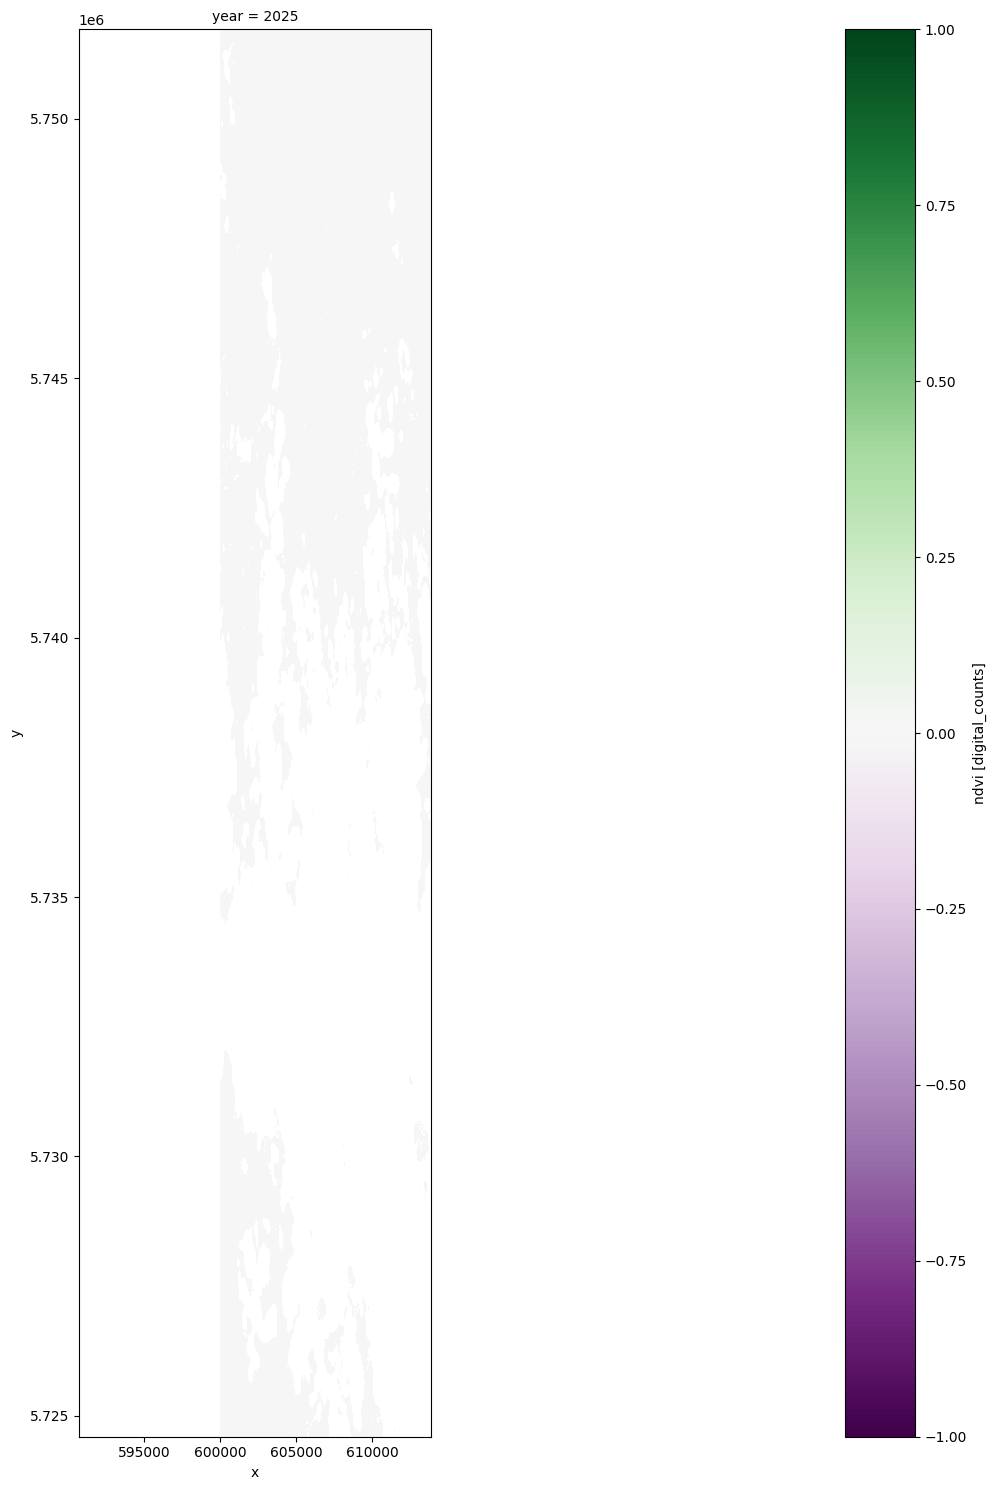

In [24]:
ndvi_yearly = yearly_ds["ndvi"].sel(x=x_slice, y=y_slice).sel(year=slice(2024, 2025))

ndvi_yearly.plot(
    cmap="PRGn", x="x", y="y", col="year", col_wrap=2, vmin=-1, vmax=1, figsize=(10, 15)
)

In [25]:
%%time
encoding = {}
for var in region.data_vars:
    encoding[var] = {"dtype": "float32"}
region.to_zarr("data_region.zarr", zarr_format=2, encoding=encoding, mode="w")

<timed exec>:4: SerializationWarning: saving variable None with floating point data as an integer dtype without any _FillValue to use for NaNs
<timed exec>:4: SerializationWarning: saving variable None with floating point data as an integer dtype without any _FillValue to use for NaNs
D:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\distributed\client.py:3374: UserWarning: Sending large graph of size 90.36 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: total: 20.9 s
Wall time: 30.5 s


In [26]:
from modules.utils import to_km2

yearly_ds["FOREST"] = yearly_ds.ndvi > 0.7

resolution = (100, 100)
forest_pixels = yearly_ds.sel(x=x_slice, y=y_slice).FOREST.sum(["x", "y"])
forest_area_km2 = to_km2(forest_pixels, resolution)
forest_area_km2

<xarray.DataArray 'FOREST' (year: 1)> Size: 8B
dask.array<truediv, shape=(1,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * year         (year) int64 8B 2025
    spatial_ref  int64 8B 0
Attributes: (11)

In [ ]:
forest_area_km2.plot()

plt.title("Forest Cover")
plt.ylabel("Forest Cover [km²]")
plt.ylim(0);

In [ ]:
# Make change maps of forest loss and forest gain compared to previous year

# 0 - 0 = No Change: 0
# 1 - 1 = No Change: 0
# 1 - 0 = Forest Gain: 1
# 0 - 1 = Forest Loss: -1

# Define custom colors and labels
colors = ["darkred", "white", "darkblue"]
labels = ["Forest Loss", "No Change", "Forest Gain"]

# Create a colormap and normalize it
cmap = mcolors.ListedColormap(colors)
norm = plt.Normalize(-1, 1)  # Adjust the range based on your data

In [ ]:
plot_year = 2022
yearly_ds["CHANGE"] = yearly_ds.FOREST.astype(int).diff("year", label="upper")
yearly_ds["CHANGE"].compute()

In [ ]:
yearly_ds.CHANGE.sel(year=plot_year).plot(cmap=cmap, norm=norm, add_colorbar=False)
# Create a legend with string labels
legend_patches = [
    mpatches.Patch(color=color, label=label) for color, label in zip(colors, labels)
]
plt.legend(handles=legend_patches, loc="lower left")
plt.title(f"Forest Change Map {plot_year}");

In [ ]:
# Forest Loss per Year
forest_loss = (yearly_ds.CHANGE == -1).sum(["x", "y"])
forest_loss_km2 = to_km2(forest_loss, resolution)
forest_loss_km2.cumsum().plot()
plt.title("Cumulative Forest Loss")
plt.ylabel("Forest Loss [km²]");